# 04. Model Training & Evaluation - Supervised Learning

## Overview
This notebook trains, evaluates, and compares multiple supervised classification models for **Loan Approval Prediction**:
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **Gradient Boosting Classifier**

All performance metrics, confusion matrices, feature importances, and ROC curves are exported as visual figures to `../reports/figures/` for the final Supervised Learning report handoff package.


## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "Arial"

figures_dir = "../reports/figures"
os.makedirs(figures_dir, exist_ok=True)

df = pd.read_csv("../data/processed/cleaned_loan_data.csv")
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split ready: Train={len(X_train)}, Test={len(X_test)}")

Data split ready: Train=800, Test=200


## 2. Model Instantiation & Training

In [2]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = []
trained_models = {}
probabilities = {}
predictions = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })
    
    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_prob

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-Score", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.995,0.990099,1.00,0.995025,0.99990
1,Gradient Boosting,0.975,0.970297,0.98,0.975124,0.99580
2,Random Forest,0.970,0.970000,0.97,0.970000,0.99695
3,Decision Tree,0.960,0.969388,0.95,0.959596,0.97140


## 3. Model Performance Comparison Chart

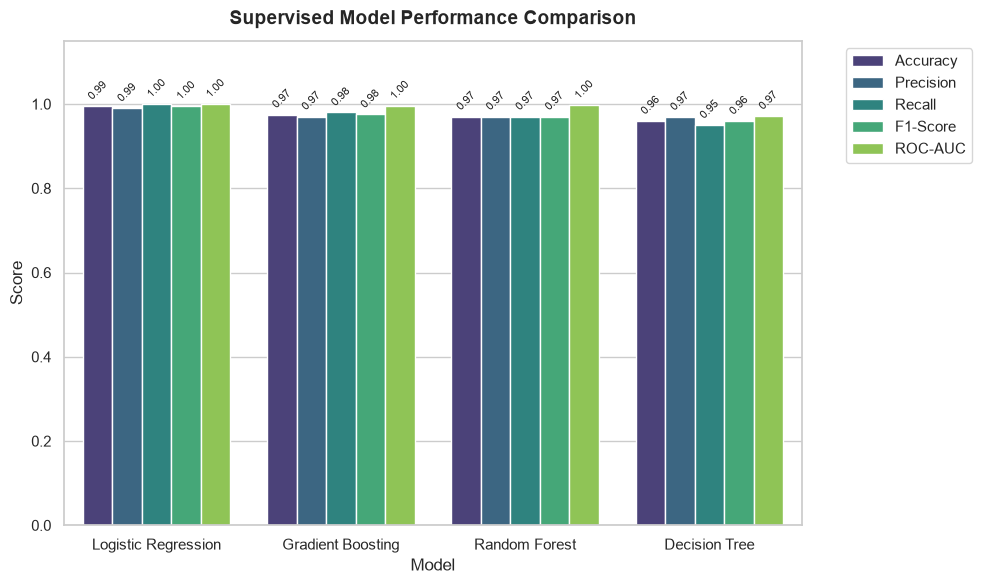

Saved model performance comparison plot to ../reports/figures\model_performance_comparison.png


In [3]:
plt.figure(figsize=(10, 6))
df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Supervised Model Performance Comparison", fontsize=14, fontweight='bold', pad=12)
plt.ylim(0, 1.15)
plt.ylabel("Score", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.2f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, rotation=45, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
fig_path = os.path.join(figures_dir, "model_performance_comparison.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved model performance comparison plot to {fig_path}")

## 4. Feature Importance Comparison (Tree Models)

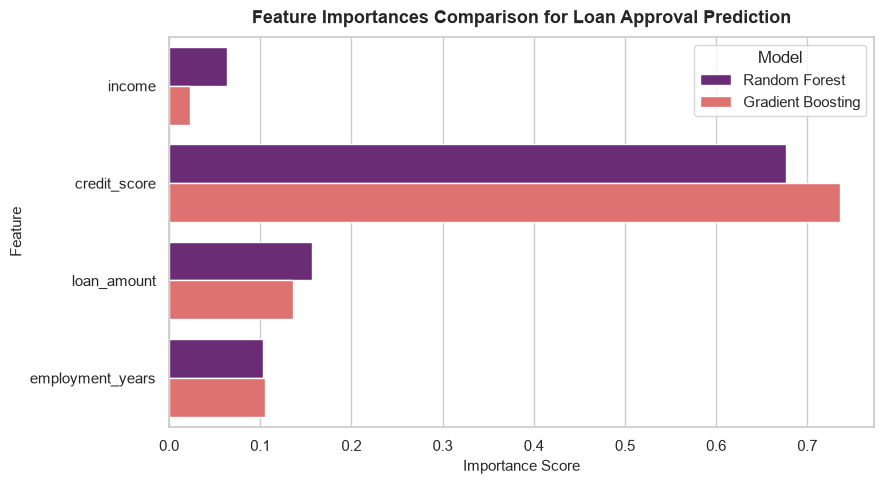

Saved feature importance plot to ../reports/figures\feature_importance.png


In [4]:
rf_imp = trained_models["Random Forest"].feature_importances_
gb_imp = trained_models["Gradient Boosting"].feature_importances_

feature_imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest": rf_imp,
    "Gradient Boosting": gb_imp
}).melt(id_vars="Feature", var_name="Model", value_name="Importance")

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_imp_df, x="Importance", y="Feature", hue="Model", palette="magma")
plt.title("Feature Importances Comparison for Loan Approval Prediction", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Importance Score", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.tight_layout()

fig_path = os.path.join(figures_dir, "feature_importance.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved feature importance plot to {fig_path}")

## 5. Confusion Matrices Evaluation Grid

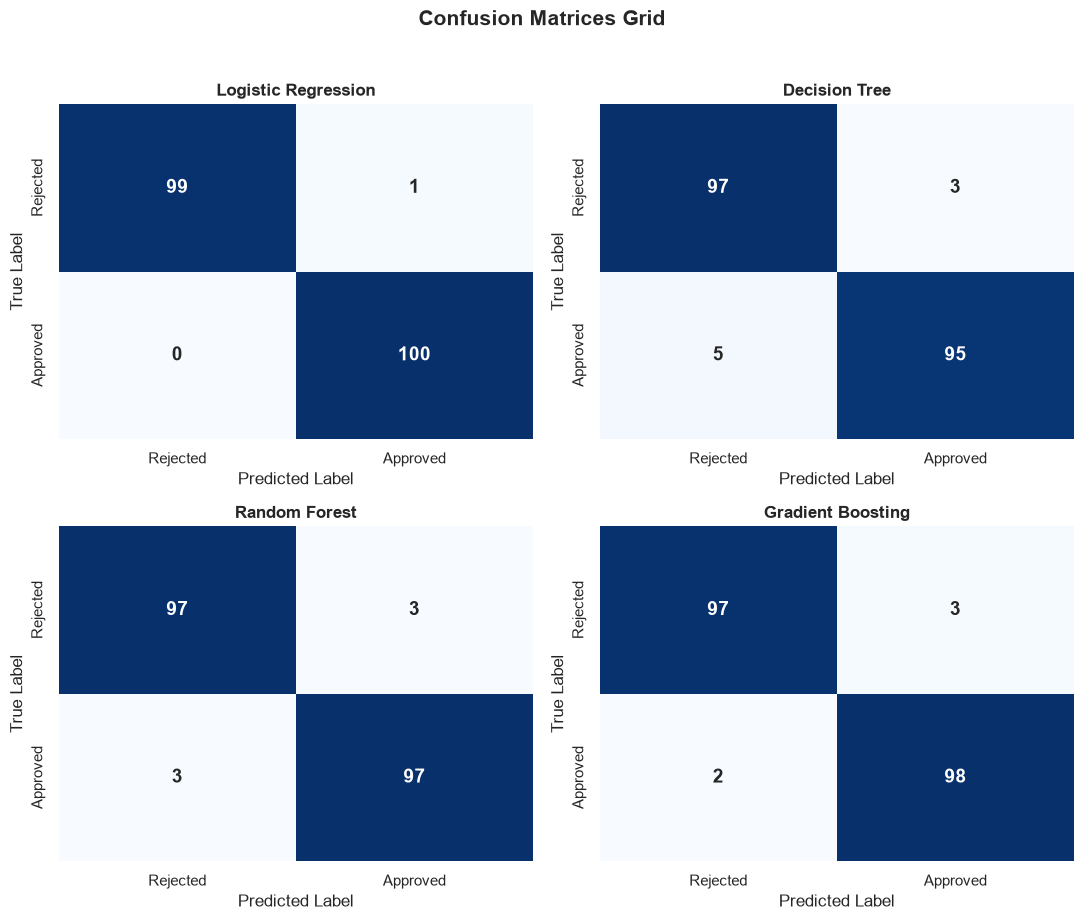

Saved confusion matrices plot to ../reports/figures\confusion_matrices.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    axes[idx].set_title(f"{name}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xticklabels(["Rejected", "Approved"])
    axes[idx].set_yticklabels(["Rejected", "Approved"])

plt.suptitle("Confusion Matrices Grid", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

fig_path = os.path.join(figures_dir, "confusion_matrices.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved confusion matrices plot to {fig_path}")

## 6. ROC Curves & AUC Score Analysis

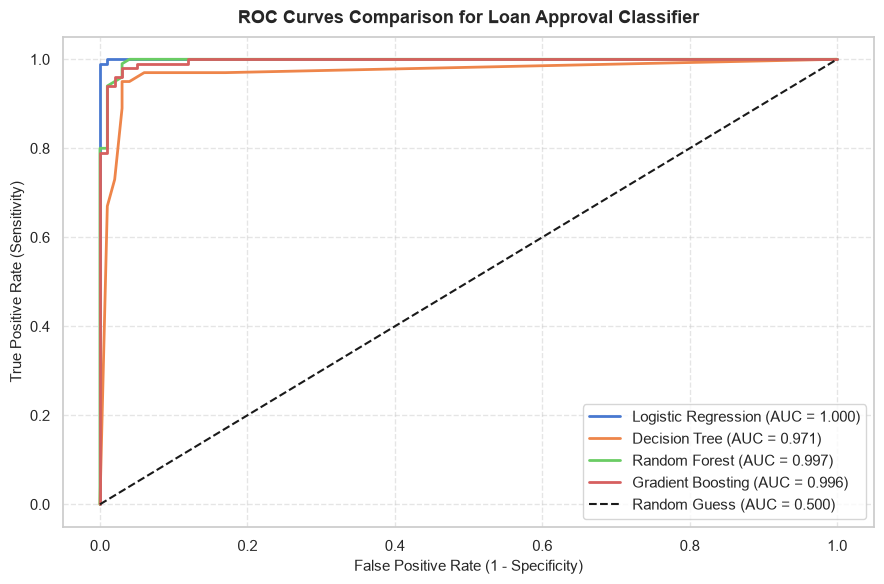

Saved ROC curves plot to ../reports/figures\roc_curves.png


In [6]:
plt.figure(figsize=(9, 6))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Guess (AUC = 0.500)")
plt.title("ROC Curves Comparison for Loan Approval Classifier", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig_path = os.path.join(figures_dir, "roc_curves.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved ROC curves plot to {fig_path}")

## 7. Model Persistence (Save Best Model)

In [7]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best Performing Model based on F1-Score: {best_model_name}")

model_output_path = "../notebooks/loan_approval_model.pkl"
joblib.dump(best_model, model_output_path)
print(f"Saved trained model object to {model_output_path}")

Best Performing Model based on F1-Score: Logistic Regression
Saved trained model object to ../notebooks/loan_approval_model.pkl
